# Normal approximation to the binomial distribution

## Problem 7-24
Find the probability of getting between $3$ and $6$ heads inclusive in $10$ tosses of a fair coin by using (a) the binomial distribution and (b) the normal approximation to the binomial distribution.

### Solution

(a)
\begin{align}
\text{Pr}\{\ 3 \text{ heads}\ \} = \binom{10}{3} \left( \frac{1}{2} \right)^2 \left( \frac{1}{2} \right)^7 = \frac{15}{128}
 \ \ \ \ \ \ \ \ \ \ \ \ \ \ 
\text{Pr}\{\ 5 \text{ heads}\ \} = \binom{10}{5} \left( \frac{1}{2} \right)^5 \left( \frac{1}{2} \right)^5 = \frac{63}{256} \\
\text{Pr}\{\ 4 \text{ heads}\ \} = \binom{10}{4} \left( \frac{1}{2} \right)^4 \left( \frac{1}{2} \right)^6 = \frac{105}{512}
 \ \ \ \ \ \ \ \ \ \ \ \ \ \ 
\text{Pr}\{\ 6 \text{ heads}\ \} = \binom{10}{6} \left( \frac{1}{2} \right)^6 \left( \frac{1}{2} \right)^4 = \frac{105}{512}
\end{align}

Thus
\begin{align}
\text{Pr}\{\ \text{between 3 and 6 heads inclusive}\ \} = \frac{15}{128} + \frac{105}{512} + \frac{63}{256} + \frac{105}{512} = \frac{99}{128} = 0.7734
\end{align}

In [1]:
p7.24 <- new.env()
(p7.24$probs <- dbinom(x=3:6, size=10, prob=0.5))
sum(p7.24$probs)

[1] 0.1171875 0.2050781 0.2460938 0.2050781

[1] 0.7734375

(b)  

The binomial distribution for $N=10$ tosses of a fair coin is shown in Fig. 7-13.  

Note that even though the binomial distribution is discrete, it has the shape of the continuous normal distribution. When approximating the binomial probability at $3, 4, 5,$ and $6$ heads by the area under the normal curve, find the normal curve area from $X=2.5$ to $X=6.5$. The $0.5$ that you go on either side of $X=3$ and $X=6$ is called the _continuity correction_. The following are the steps to follow when approximating the binomial with the normal. Choose the normal curve with mean when approximating the binomial with the normal. Choose the normal curve with mean = $N_p=10(0.5)=5$ and standard deviation $=\sqrt{N_{pq}}=\sqrt{10(0.5)(0.5)}=1.58$. You are choosing the normal curve with the same center and variation as the binomial distribution. Then find the area under the curve from $2.5$ to $6.5$ as shown in Fig. 7-14. This is the normal approximation to the binomial distribution.  

The solution when using the normal distribution function is given below.

In [2]:
pnorm(6.5,5,1.58) - pnorm(2.5, 5, 1.58)

[1] 0.77199

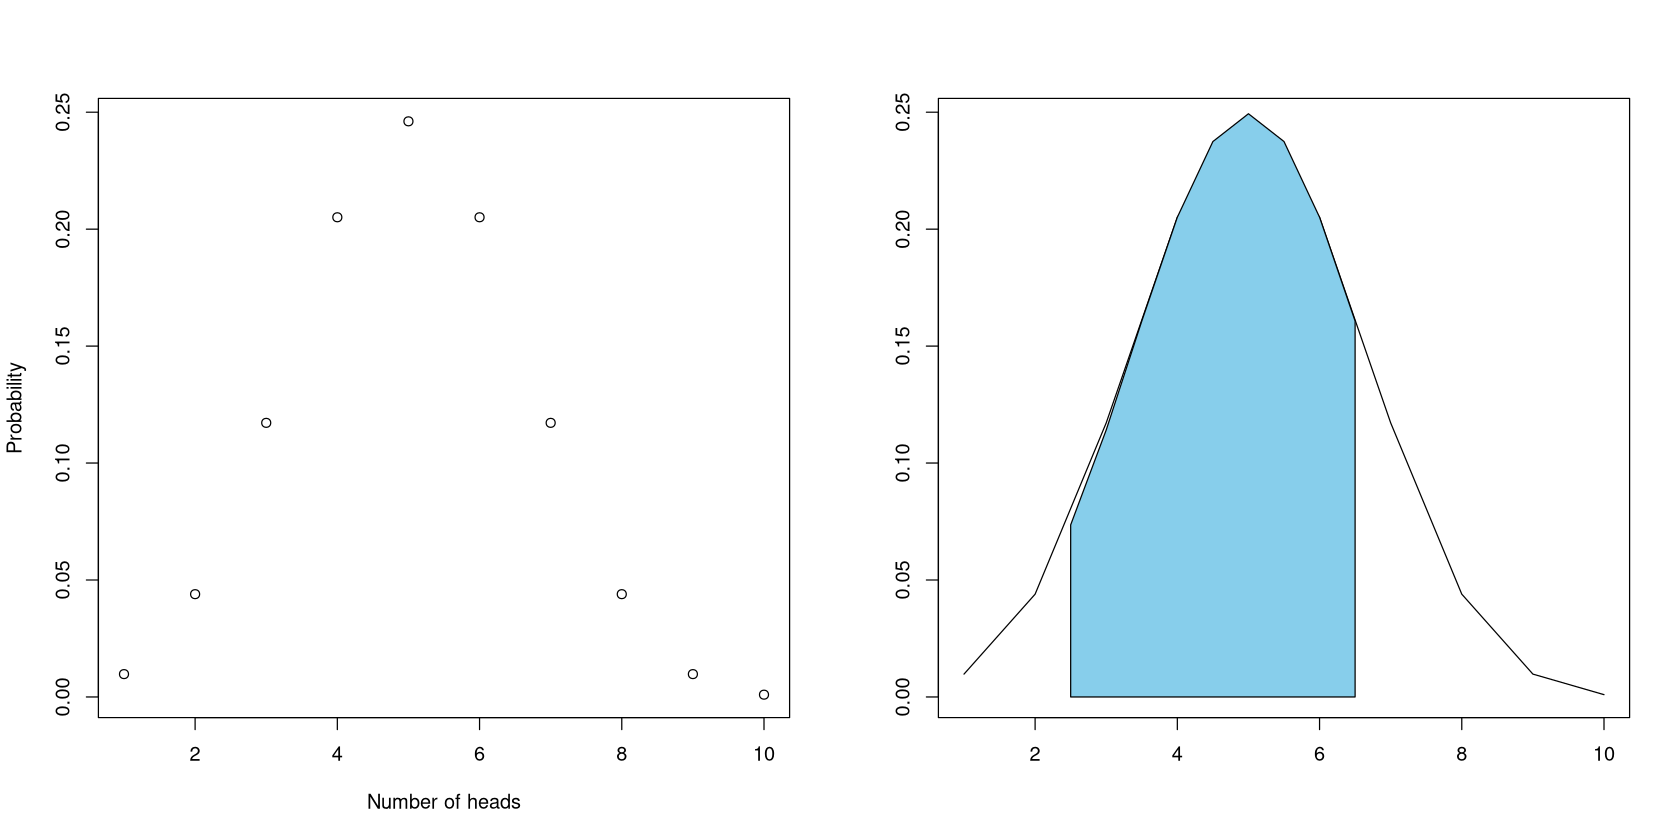

In [3]:
par(mfrow=c(1,2))
options(repr.plot.width=14, repr.plot.height=7)
plot(dbinom(1:10,10,.5), xlab="Number of heads", ylab="Probability")
p7.24$x <- seq(2.5, 6.5,by=.5)
p7.24$y <- c(0,dnorm(p7.24$x, 5, 1.6),0)
plot(dbinom(1:10,10,.5), xlab="", ylab="", type="l")
polygon(c(2.5, p7.24$x, 6.5), p7.24$y, col="skyblue")

If the technique using Appendix II is applied, the normal values $6.5$ and $2.5$ are first converted to standard normal values. ($2.5$ in standard units is $-1.58$ and $6.5$ in standard units is $0.95$.) The area between $-1.58$ and $0.95$ from Appendix II is $0.7718$. Whichever method is used the answer is very close to the binomial answer of $0.7734$.

In [4]:
rm(p7.24)

---

## Problem 7-25
A fair coin is tossed $500$ times. Find the probability that the number of heads will not differ from $250$ by (a) more than $10$ and (b) more than $30$.

### Solution
\begin{align}
\mu = N_p = (500)\frac{1}{2}=250 \ \ \ \ \ \ \ \ \sigma = \sqrt{N_{pq}}=\sqrt{(500)\frac{1}{2} \frac{1}{2}} = 11.18
\end{align}

In [5]:
p7.25 <- new.env()
p7.25$mu <- 500*.5
p7.25$sigma <- sqrt((500*.5*.5))

(a) We require the probability that the number of heads will lie between $240$ and $260$ or, considering the data to be continuous, between $239.5$ and $260.5$. Since $239.5$ in standard units is $(239.5 - 250)/11.18=-0.94$, and $260.5$ in standard units is $0.94$, we have
\begin{align}
\text{Required probability} &= (\text{area under normal curve between } z = -0.94 \text{ and } z = 0.94) \\
                            &= (\text{twice area between } z = 0 \text{ and } z = 0.94) = 2(0.3264) = 0.6528
\end{align}

In [6]:
cat("Using the dbinom function: ", sum(dbinom(240:260, 500, .5)), "\n")
cat("Considering the data to be continuous: ", sum(dnorm(seq(239.5, 260.5, .5), 250, 11.18)), "\n")

Using the dbinom function:  0.6523358 
Considering the data to be continuous:  1.327518 


(b) We require the probability that the number of heads will lie between $220$ and $280$ or, considering the data to be continuous, between $219.5$ in standard units is $(219.5 - 250)/11.18=-2.73$, and $280.5$ in standard units is $2.73$, we have
\begin{align}
\text{Required probability} &= (\text{ twice area under normal curve between } z = 0 \text{ and } z = -2.73) \\
                            &= 2(0.4968) = 0.9936
\end{align}

It follows that we can be very confident that the number of heads will not differ from the expected $(250)$ by more than $30$. THus if it turned out that the _actual_ number of heads was $280$, we would strongly believe that the coin was not fair (i.e., was loaded).

In [7]:
cat("Using the dbinom function: ", sum(dbinom(220:280, 500, .5)), "\n")
cat("Considering the data to be continuous: ", sum(dnorm(seq(219.5, 280.5, .5), 250, 11.18)), "\n")

Using the dbinom function:  0.9936847 
Considering the data to be continuous:  1.988106 


In [8]:
rm(p7.25)

---

## Problem 7-26

Suppose 75% of the age group 1 through 4 years regularly utilize seat belts. Find the probability that in a random stop of 100 automobiles containing 1 through 4 year olds, 70 or fewer are found to be wearing a seat belt. Find the solution using the binomial distribution as well as the normal approximation to the binomial distribution.

In [9]:
p7.26 <- new.env()
p7.26$mu <- 100*.75
p7.26$sigma <- sqrt(100*.75*.25)
cat("Binormal distribution: ", pbinom(70, 100, .75), "\n")
cat("Normal approximation for distribution: ", pnorm(70.5, p7.26$mu, p7.26$sigma), "\n")

Binormal distribution:  0.149541 
Normal approximation for distribution:  0.1493488 


In [10]:
rm(p7.26)

---